In [26]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from calibration import lifetime_to_temperature_201112
from scipy.optimize import curve_fit
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

In [27]:
file_path = glob.glob('./continuous/2009??_IRheating_lin22.6_100mW_5000ms_26/cyto/*.csv')
file_path.sort()

In [28]:
#t=0で切り取る
result_continuous = 0
data_set_continuous = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    temperature = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+100]
    result_continuous += temperature
    data_set_continuous = pd.concat([data_set_continuous, pd.DataFrame(temperature)], axis = 1)
    
result_continuous = result_continuous/len(file_path)
result_continuous = result_continuous - np.mean(result_continuous[:10])

In [29]:
file_path = glob.glob('./pulse/210512_relaxation_100ms_26_200mW/*.csv')
file_path.sort()

In [30]:
#t=0で切り取る
result_pulse = 0
data_set_pulse = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    temperature = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-50: index+150]
    result_pulse += temperature
    data_set_pulse = pd.concat([data_set_pulse, pd.DataFrame(temperature)], axis = 1)
    
result_pulse = result_pulse/len(file_path)
result_pulse = result_pulse - np.mean(result_pulse[:10])

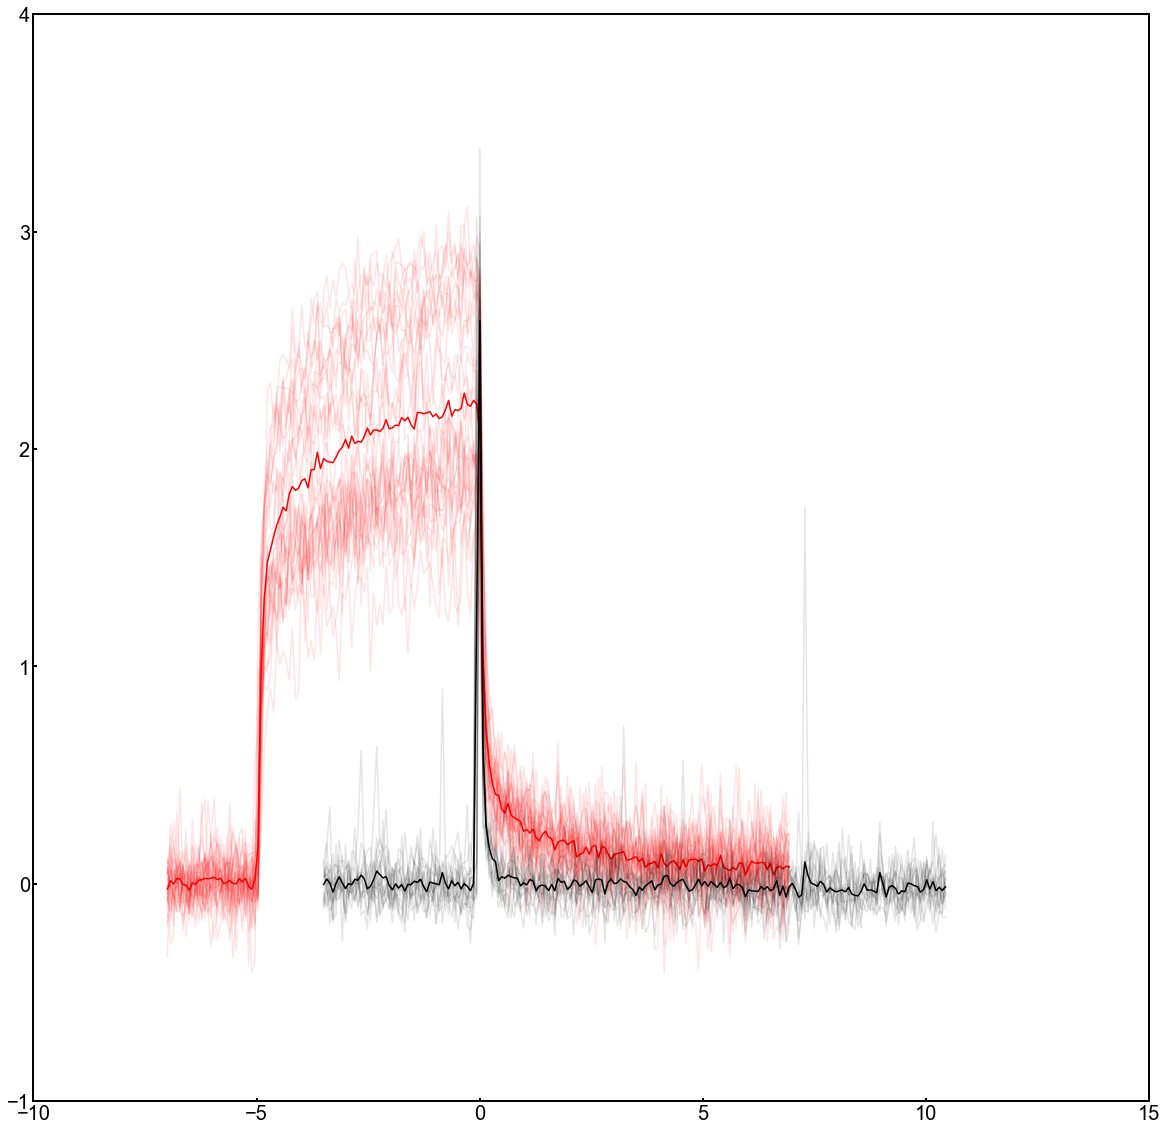

In [31]:
fig = plt.figure(figsize=(20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 20)


time_continuos = [(i-100)*0.07 for i in range(len(result_continuous))]
time_pulse = [(i-50)*0.07 for i in range(len(result_pulse))]
plt.plot(time_continuos, result_continuous, color = 'red')
plt.plot(time_continuos, data_set_continuous - data_set_continuous.iloc[:10, :].mean(), color = 'red', alpha = 0.1)
plt.plot(time_pulse, result_pulse, color = 'black')
plt.plot(time_pulse, data_set_pulse - data_set_pulse.iloc[:10, :].mean(), color = 'black', alpha = 0.1)

plt.ylim(-1, 4)
plt.xlim(-10, 15)



#pdfのセーブ
pp = PdfPages('./Fig3d_outline.pdf')
pp.savefig(fig)
pp.close()

/var/folders/6w/hyvmhz8n61s0fqn11gs2dkfr0000gn/T/ipykernel_2730/398862340.py:52: RuntimeWarning: overflow encountered in exp
  return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)


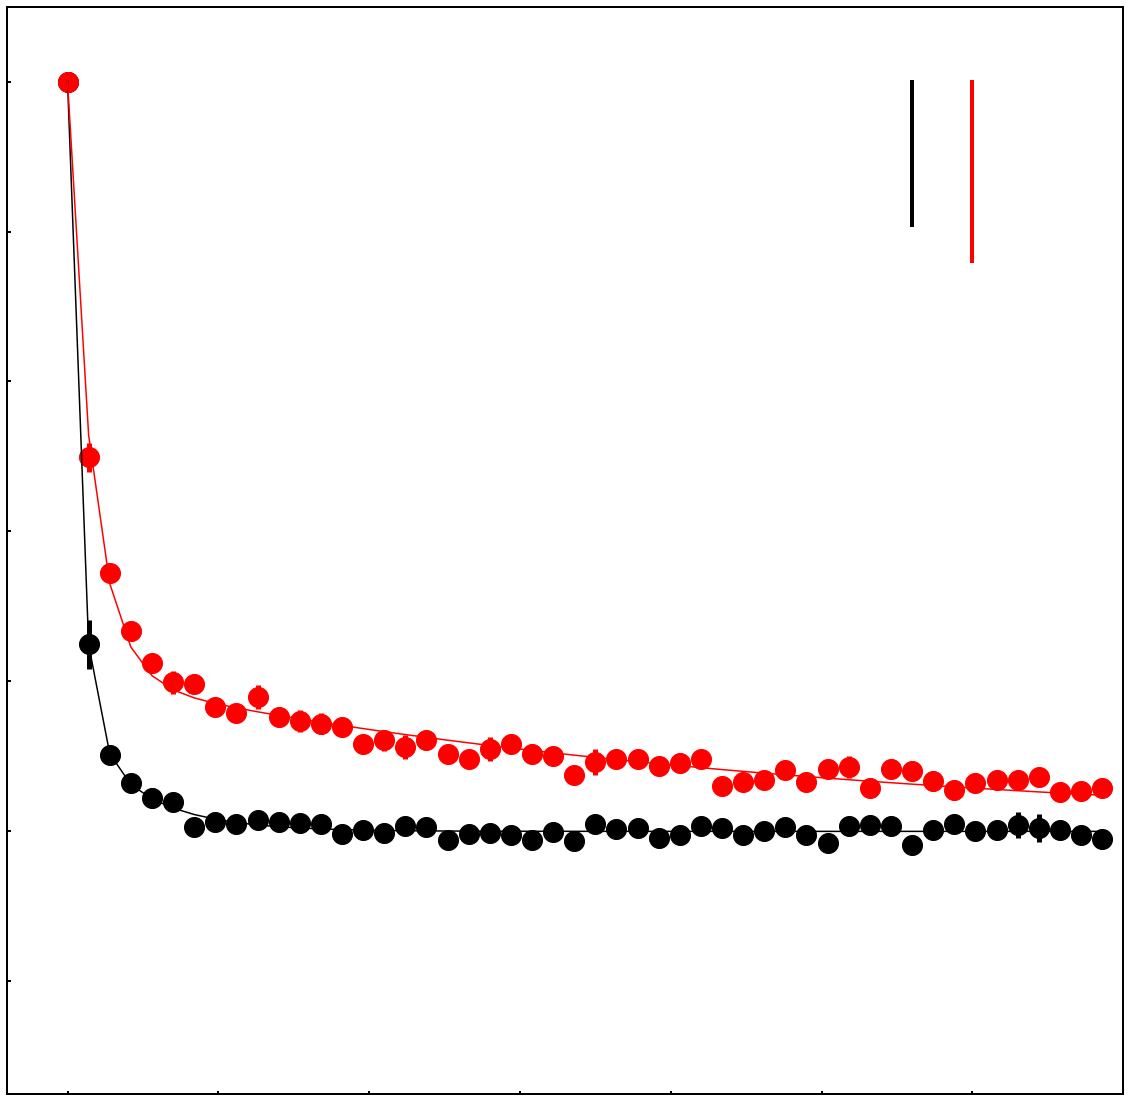

In [32]:
result_relaxation_continuous = result_continuous[100:150]
result_relaxation_pulse = result_pulse[50:100]


#実測データのプロット
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
time_relaxation_continuous = [(i)*0.07 for i in range(len(result_relaxation_continuous))]
time_relaxation_pulse = [(i)*0.07 for i in range(len(result_relaxation_pulse))]


#SEMの計算
data_set_pulse = data_set_pulse - np.mean(data_set_pulse.iloc[:10, :])
data_set_pulse = data_set_pulse/data_set_pulse.iloc[50, :]*100
sem_pulse = data_set_pulse.sem(axis = 1)
sem_pulse[50] = 0

data_set_continuous = data_set_continuous - np.mean(data_set_continuous.iloc[:10, :])
data_set_continuous = data_set_continuous/data_set_continuous.iloc[100, :]*100
sem_continuous = data_set_continuous.sem(axis = 1)
sem_continuous[100] = 0


#1˚Cを示すバーを挿入
pulse_bar = [100 - 50/result_relaxation_pulse[0]*i/100 for i in range(100)]
pulse_bar_pos = [2.8 for i in range(len(pulse_bar))]
plt.plot(pulse_bar_pos, pulse_bar, linewidth = 4, color = 'Black', linestyle = '-')

#1˚Cを示すバーを挿入
continuous_bar = [100 - 50/result_relaxation_continuous[0]*i/100 for i in range(100)]
continuous_bar_pos = [3.0 for i in range(len(continuous_bar))]
plt.plot(continuous_bar_pos, continuous_bar, linewidth = 4, color = 'red', linestyle = '-')

#規格化
result_relaxation_pulse = result_relaxation_pulse/result_relaxation_pulse[0]
result_relaxation_continuous = result_relaxation_continuous/result_relaxation_continuous[0]


plt.errorbar(time_relaxation_pulse, result_relaxation_pulse*100, yerr = np.ravel(sem_pulse)[50:100], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='Black')
plt.errorbar(time_relaxation_continuous, result_relaxation_continuous*100, yerr = np.ravel(sem_continuous)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time_relaxation_pulse, result_relaxation_pulse*100, color = 'Black', markersize = 20, marker = 'o', linewidth = 0)
plt.plot(time_relaxation_continuous, result_relaxation_continuous*100, color = 'red', markersize = 20, marker = 'o', linewidth = 0)
plt.tick_params(labelbottom=False,
                labelleft=False,
                labelright=False,
                labeltop=False)



#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result_pulse = curve_fit(relaxation, time_relaxation_pulse, result_relaxation_pulse)[0]
result_continuous = curve_fit(relaxation, time_relaxation_continuous, result_relaxation_continuous)[0]


plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)

#fitting結果の図示
plt.plot(time_relaxation_pulse, relaxation(np.ravel(time_relaxation_pulse), result_pulse[0], result_pulse[1], result_pulse[2])*100, color = 'Black')
plt.plot(time_relaxation_continuous, relaxation(np.ravel(time_relaxation_continuous), result_continuous[0], result_continuous[1], result_continuous[2])*100, color = 'red')

'''
#10%線の図示
line_x_pos = np.linspace(-1, time_normal_5sec[-1]+1, 200)
ten_line = [10 for i in range(len(line_x_pos))]
plt.plot(line_x_pos, ten_line, color = 'black', linestyle='dashed')
plt.xlim(0, time_normal_5sec[-1])
plt.show()
'''

#pdfのセーブ
pp = PdfPages('./Fig3d_ralaxation.pdf')
pp.savefig(fig)
pp.close()

In [33]:
#welchのt検定
sum_continuous = data_set_continuous.iloc[102:150].sum().values
sum_pulse = data_set_pulse.iloc[52:100].sum().values
stats.ttest_ind(sum_continuous, sum_pulse, equal_var = False)

Ttest_indResult(statistic=17.72490162066166, pvalue=2.263466733473468e-21)

In [34]:
sem_continuous_bar = (sum_continuous*0.07).std(ddof = 1)/np.sqrt(len(sum_continuous))
sem_pulse_bar = (sum_pulse*0.07).std(ddof = 1)/np.sqrt(len(sum_pulse))

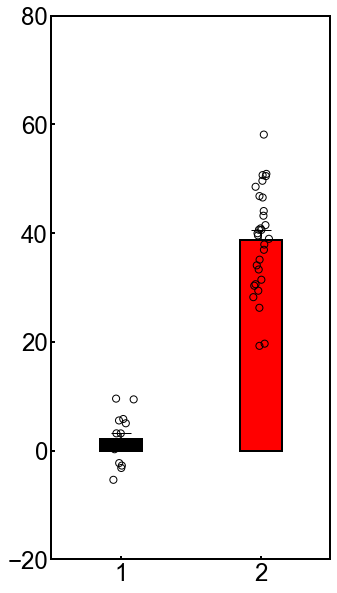

In [35]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_continuous_ave = np.average(sum_continuous*0.07)
sum_pulse_ave = np.average(sum_pulse*0.07)


plt.bar(2, sum_continuous_ave, yerr = [[0], [sem_continuous_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_continuous)) 
plt.scatter(x, sum_continuous*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)

plt.bar(1, sum_pulse_ave, yerr = [[0], [sem_pulse_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_pulse)) 
plt.scatter(x, sum_pulse*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)


plt.ylim(-20, 80)
plt.xlim(0.5, 2.5)

#pdfのセーブ
pp = PdfPages('./Fig3d_ralaxation_bar.pdf')
pp.savefig(fig)
pp.close()

In [36]:
(data_set_pulse - data_set_pulse.iloc[:10, :].mean()).to_csv('pulse_all.csv')
pd.DataFrame(result_pulse).to_csv('pulse_ave.csv')

In [37]:
(data_set_continuous - data_set_continuous.iloc[:10, :].mean()).to_csv('continuous_all.csv')
pd.DataFrame(result_continuous).to_csv('continuous_ave.csv')

In [38]:
pd.DataFrame(sum_continuous*0.07).to_csv('AUC_5sec_all.csv')
pd.DataFrame(sum_pulse*0.07).to_csv('AUC_100msec_all.csv')

In [39]:
print(sum_continuous_ave)
print(sem_continuous_bar)
print(sum_pulse_ave)
print(sem_pulse_bar)

38.788883
1.7186289856145676
2.114253
1.1521705866012015


In [40]:
pd.DataFrame(result_relaxation_pulse*100).to_csv('pulse_normalized.csv')
pd.DataFrame(result_relaxation_continuous*100).to_csv('continuous_normalized.csv')

In [41]:
pd.DataFrame(sem_continuous[100:150]).to_csv('sem_continuous.csv')
pd.DataFrame(sem_pulse[50:100]).to_csv('sem_pulse.csv')